# Lab 2: Classification Using KNN and Radius Neighbors
Student: [Your Name]

Course: MSCS-634 Advanced Big Data and Data Mining


This notebook evaluates the requested KNN and Radius Neighbors values with a stratified 80/20 Wine split.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

wine = load_wine()
X, y = wine.data, wine.target
features = pd.DataFrame(X, columns=wine.feature_names)
print(f"Samples: {X.shape[0]}; features: {X.shape[1]}")
display(features.describe().T)
display(pd.Series(y).value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))).to_frame("count"))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, stratify=y, random_state=42)
print("Training:", len(X_train), "Test:", len(X_test))


Samples: 178; features: 13


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


,count
class_0,59
class_1,71
class_2,48


Training: 142 Test: 36


In [2]:
k_values = [1, 5, 11, 15, 21]
knn_results = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    knn_results.append({"k":k, "accuracy":accuracy_score(y_test, model.predict(X_test))})
knn_results = pd.DataFrame(knn_results)
display(knn_results)


,k,accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


In [3]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_results = []
for radius in radius_values:
    model = RadiusNeighborsClassifier(radius=radius, outlier_label="most_frequent").fit(X_train, y_train)
    rnn_results.append({"radius":radius, "accuracy":accuracy_score(y_test, model.predict(X_test))})
rnn_results = pd.DataFrame(rnn_results)
display(rnn_results)


,radius,accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


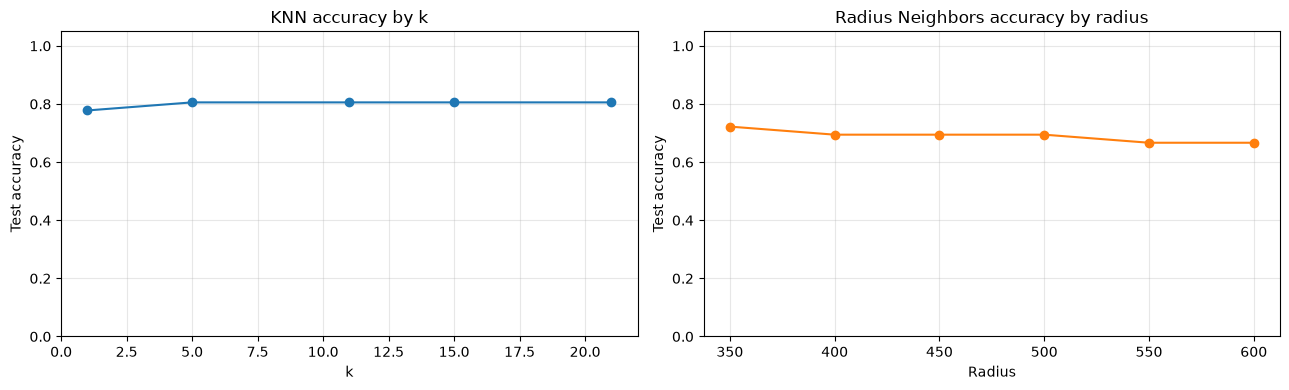

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(knn_results.k, knn_results.accuracy, marker="o")
axes[0].set(title="KNN accuracy by k", xlabel="k", ylabel="Test accuracy", ylim=(0,1.05)); axes[0].grid(alpha=.3)
axes[1].plot(rnn_results.radius, rnn_results.accuracy, marker="o", color="tab:orange")
axes[1].set(title="Radius Neighbors accuracy by radius", xlabel="Radius", ylabel="Test accuracy", ylim=(0,1.05)); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## Observations
KNN uses a fixed number of nearest examples. Smaller k may be sensitive to local noise, whereas larger k smooths decisions. Radius Neighbors uses a fixed distance threshold, so its results depend heavily on feature scale and local density. The raw-feature radius values were retained as assigned; scaling is a useful follow-up experiment but would change their meaning.
